# Deep Learning: LSTM GRU for Fake Review Detection

## 1. Introduction
While traditional Machine Learning models (like Naive Bayes or SVM) work well with frequency-based features (TF-IDF), they often ignore the **sequential nature** of language. Deep Learning models, specifically Recurrent Neural Networks (RNNs), are designed to process data in sequences.

In this notebook, we implement a **Bidirectional GRU (Gated Recurrent Unit)** model. 
- **GRU:** A streamlined version of LSTM that is computationally efficient while still capturing long-term dependencies in text.
- **Bidirectional:** Processes the review from both start-to-finish and finish-to-start, allowing the model to understand the full context of a word based on its surroundings.

This notebook serves as a clean, documented baseline for our deep learning approach.

---


In [1]:
import os
import pandas as pd
import joblib
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout, Bidirectional, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

INPUT_PATH = "../data/preprocessed/cleaned_reviews.csv"
OUTPUT_DIR = "../data/processed"
os.makedirs(OUTPUT_DIR, exist_ok=True)

MAX_WORDS = 10000
EMBEDDING_DIM = 128


## 2. Data Loading & Preprocessing
We load the preprocessed text from our previous steps. Unlike TF-IDF, which creates a sparse matrix of word importance, deep learning models require:
1.  **Tokenization**: Converting words into unique integer IDs.
2.  **Padding**: Ensuring all reviews have the same length so they can be processed in batches by the GPU/CPU.

We define a few key constants:
- `MAX_WORDS`: The size of our vocabulary (top 10,000 most frequent words).
- `MAX_LEN`: The fixed length for every review. We set this to the **95th percentile** of review lengths to capture most content while keeping the model efficient.

---


In [2]:
df = pd.read_csv(INPUT_PATH)
df['cleaned_review'] = df['cleaned_review'].fillna('')

X = df['cleaned_review']
y = df['label_binary']

review_lengths = [len(str(text).split()) for text in X]
MAX_LEN = int(np.percentile(review_lengths, 95))
print(f"95th percentile of review length: {MAX_LEN}")

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X)

X_seq = tokenizer.texts_to_sequences(X)
X_pad = pad_sequences(X_seq, maxlen=MAX_LEN, padding='post', truncating='post')

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_pad, y, test_size=0.20, random_state=SEED, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.125, random_state=SEED, stratify=y_train_val
)

print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Testing samples: {len(X_test)}")


95th percentile of review length: 105
Training samples: 28301
Validation samples: 4044
Testing samples: 8087


## 3. Model Building & Training
Our architecture consists of:
1.  **Input Layer**: Explicitly defines the input shape.
2.  **Embedding Layer**: Learns a dense vector representation (128 dimensions) for each word, capturing semantic relationships.
3.  **Bidirectional GRU**: The core engine that analyzes the sequence of word embeddings.
4.  **Dropout**: A regularization technique that randomly "turns off" neurons during training to prevent the model from memorizing the training data (overfitting).
5.  **Dense Output**: A single neuron with a **Sigmoid** activation function to output a probability between 0 (Real) and 1 (Fake).

We use multiple **callbacks** to optimize training:
- **Early Stopping**: Stop training if `val_loss` stops improving.
- **ReduceLROnPlateau**: Lower the learning rate if the model hits a plateau.
- **Model Checkpoint**: Save the best version of the model during training.

---


In [3]:
model = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(MAX_WORDS + 1, EMBEDDING_DIM),
    Bidirectional(GRU(64)),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=0.0001, verbose=1),
    ModelCheckpoint(os.path.join(OUTPUT_DIR, "best_deep_learning_model.keras"), 
                    monitor='val_loss', save_best_only=True, verbose=1)
]

history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=callbacks
)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 105, 128)       │     1,280,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        74,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,354,753 (5.17 MB)

 Trainable params: 1,354,753 (5.17 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
443/443 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.7235 - loss: 0.5008
Epoch 1: val_loss improved from None to 0.24448, saving model to ../data/processed\best_deep_learning_model.keras

Epoch 1: finished saving model to ../data/processed\best_deep_learning_model.keras
443/443 ━━━━━━━━━━━━━━━━━━━━ 37s 76ms/step - accuracy: 0.8235 - loss: 0.3683 - val_accuracy: 0.8964 - val_loss: 0.2445 - learning_rate: 0.0010
Epoch 2/15
442/443 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9200 - loss: 0.1962
Epoch 2: val_loss improved from 0.24448 to 0.23329, saving model to ../data/processed\best_deep_learning_model.keras

Epoch 2: finished saving model to ../data/processed\best_deep_learning_model.keras
443/443 ━━━━━━━━━━━━━━━━━━━━ 33s 74ms/step - accuracy: 0.9276 - loss: 0.1800 - val_accuracy: 0.9008 - val_loss: 0.2333 - learning_rate: 0.0010
Epoch 3/15
443/443 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9471 - loss: 0.1352
Epoch 3: val_loss did not improve from 0.23329
443/443

## 4. Evaluation & Saving
After training, we evaluate the model on the test set to see how it performs on data it has never seen before. We calculate accuracy, precision, recall, F1-score, and ROC-AUC.

Finally, we save the artifacts:
1.  **`deep_learning_model.keras`**: The trained model in the latest Keras format.
2.  **`tokenizer.pkl`**: The mapping of words to integers, saved with `joblib`.
3.  **`metadata.json`**: Hyperparameters and final test metrics.

---


Test Accuracy: 0.9096
253/253 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step

Classification Report:
                         precision    recall  f1-score   support

          Original (OR)       0.92      0.89      0.91      4044
Computer Generated (CG)       0.90      0.93      0.91      4043

               accuracy                           0.91      8087
              macro avg       0.91      0.91      0.91      8087
           weighted avg       0.91      0.91      0.91      8087

ROC-AUC Score: 0.9712


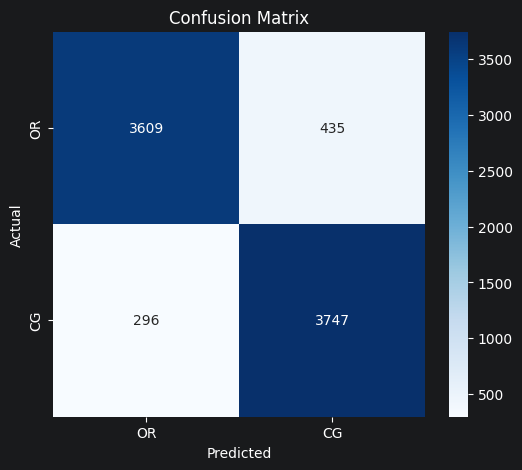

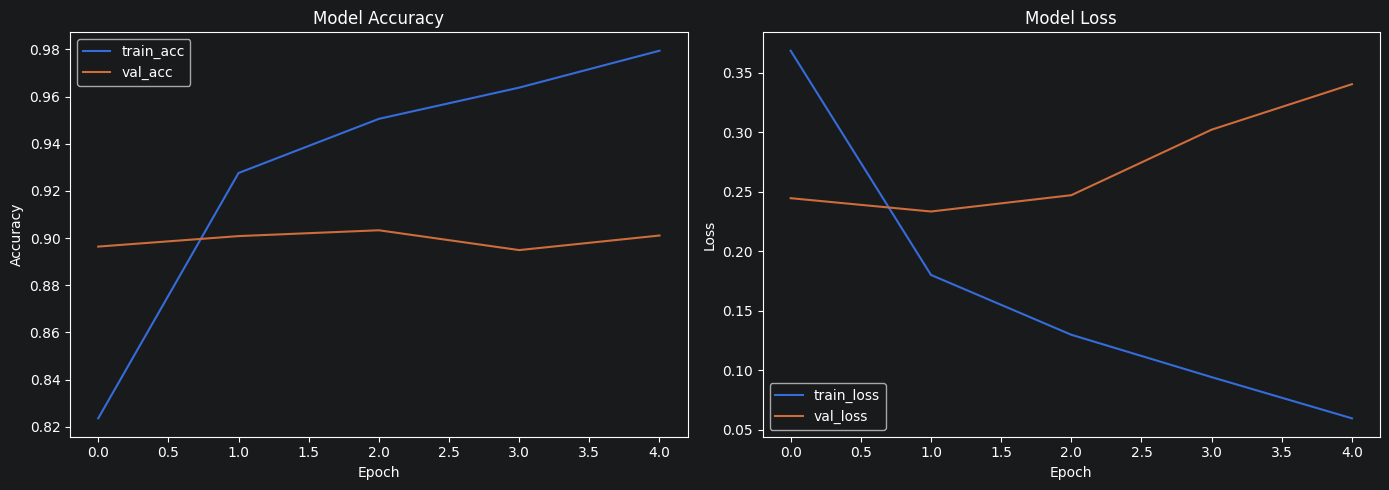

Artifacts saved to ../data/processed


In [4]:
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {acc:.4f}")

y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Original (OR)', 'Computer Generated (CG)']))

auc_score = roc_auc_score(y_test, y_pred_prob)
print(f"ROC-AUC Score: {auc_score:.4f}")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['OR', 'CG'], yticklabels=['OR', 'CG'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'], label='train_acc')
ax1.plot(history.history['val_accuracy'], label='val_acc')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(history.history['loss'], label='train_loss')
ax2.plot(history.history['val_loss'], label='val_loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

model_path = os.path.join(OUTPUT_DIR, "deep_learning_model.keras")
model.save(model_path)
joblib.dump(tokenizer, os.path.join(OUTPUT_DIR, "tokenizer.pkl"))

metadata = {
    "max_words": MAX_WORDS,
    "max_len": MAX_LEN,
    "embedding_dim": EMBEDDING_DIM,
    "test_accuracy": float(acc),
    "test_loss": float(loss),
    "roc_auc": float(auc_score),
    "seed": SEED
}

with open(os.path.join(OUTPUT_DIR, "deep_learning_metadata.json"), 'w') as f:
    json.dump(metadata, f, indent=4)

print(f"Artifacts saved to {OUTPUT_DIR}")
